<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap6_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

６章言語モデルのファインチューニング

- ファインチューニング済みエンコーダーモデルを用いたテキストのトピック分類
- 現代の LLM 時代におけるエンコーダーベースモデルの役割の理解
- デコーダーモデルを使った特定のスタイルのテキスト生成
- 命令型ファインチューニングによる単一モデルでの複数タスクの解決
- 小さいGPUでもモデルを訓練できるパラメーター効率の高いファインチューニング手法
- よりすくに計算資源でモデルの推論を実行できる手法

6.1.1 データセットの特定

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found e

In [2]:
from datasets import load_dataset

#az news データセットはテキスト分類モデルのベンチマークやデータマイニング、情報検索、データストリーミングなどの研究で広く用いられている。
# 訓練用のサンプルは１２万件あり、ファインにチューニングには十分
raw_datasets = load_dataset("fancyzhx/ag_news")
raw_datasets

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [3]:
# データの具体的な例を見ていこう

raw_train_datasets = raw_datasets["train"]
raw_train_datasets[0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

//{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

サンプルにテキストとラベルが含まれているが、２はどのクラスを指しているのか？
これを知るにはデータセットの features とその label フィールドを見ればいい。

In [4]:
print(raw_train_datasets.features)

# results
# {'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}
# 0なら世界のニュース、1ならスポーツ、2ならビジネス、３なら科学技術のニュース

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


# 6.1.2 使用するモデルタイプの定義

## Transformer おさらい

- エンコーダーモデル：入力の意味表現を捉える
- デコーダーモデル：文章などの新しいシーケンスを出力することを目的にしたモデル。テキスト生成に最適。
- エンコーダーデコーダー型モデル：入力シーケンスを異なる出力シーケンスに変換するタスクに適している

今回は、**分類ヘッド付きエンコーダーモデル**をアプローチとして採用する。
エンコーダーモデルにシンプルな分類ネットワーク（ヘッド）を埋め込みに追加してファインチューニングする方法。

ベースモデルの要件は以下の４つ

- エンコーダベースであること
- GPU を使えば数分くらいでファインチューニングできるモデル
- 事前訓練で確かな成果を残しているもの
- 短いテキストシーケンスを処理できること

DistilBERT が良さげらしい。

6.1.4 データセットの前処理

トークナイザーは AutoTokenizer を使おう。
transformers ライブラリは入力の長さがすべて同じ出なければならないので、padding=true で使おう。


In [5]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(batch):
  return tokenizer(
      batch["text"], truncation=True, padding=True, return_tensors="pt"
  )

tokenize_function(raw_train_datasets[:2])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': tensor([[  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
          1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
          2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
          1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0],
        [  101, 18431,  2571,  3504,  2646,  3293, 13395,  1006, 26665,  1007,
         26665,  1011,  2797,  5211,  3813, 18431,  2571,  2177,  1010,  1032,
          2029,  2038,  1037,  5891,  2005,  2437,  2092,  1011, 22313,  1998,
          5681,  1032,  6801,  3248,  1999,  1996,  3639,  3068,  1010,  2038,
          5168,  2872,  1032,  2049, 29475,  2006,  2178,  2112,  1997,  1996,
          3006,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 

In [6]:
# データセット内の各要素に対して関数を並列で適用するもの

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 7600
    })
})

6.1.5 評価指標の定義

評価指標には evaluate というライブラリが使える。
文章分類の場合は以下の指標が有力な候補となる。

- 正解率
- 適合率
- 再現率
- F1 スコア

evaluate が提供する指標には compute() メソッドがある。

In [7]:
import evaluate

accuracy = evaluate.load("accuracy")
print(accuracy.description)
print(accuracy.compute(references=[0, 1, 0, 1], predictions=[1, 0, 0, 1]))


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative

{'accuracy': 0.5}


In [8]:
f1_score = evaluate.load("f1")

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)

  # 精度と F1 スコアを求める
  acc_result = accuracy.compute(references=labels, predictions=preds)
  acc = acc_result["accuracy"]

  f1_result = f1_score.compute(
      references=labels, predictions=preds, average="weighted"
  )
  f1 = f1_result["f1"]

  return {"accuracy": acc, "f1": f1}

6.1.6 モデルの訓練

DistilBERT はエンコーダーモデルなので、そのまま使うと埋め込みが得られるだけなので、分類タスクには使えない。
この埋め込みを分類ヘッドに渡す必要がある。

AutoModelForSequenceClassification でモデルを読み込み、分類ヘッドでモデルを訓練する。以下の２つの処理が行われる。
- 言語モデルのヘッドを取り外して読み込む。ここはモデルのエンコーダー部分であり、各トークンに対して埋め込みを出力する
- モデルの上にランダムに初期化された分類ヘッドを追加する。このヘッドは単なる線形層であり、プーリング埋め込みを受け取り、クラスごとの確率を出力する。

In [9]:
import torch
from transformers import AutoModelForSequenceClassification

from genaibook.core import get_device

device = get_device()
num_labels = 4
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=num_labels
).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


モデルの初期化ができたのでいよいよ訓練開始。

In [10]:
from transformers import TrainingArguments
from google.colab import userdata # userdataをインポート

batch_size = 32
training_args = TrainingArguments(
    "classifier-chapter4",
    push_to_hub=True, #モデルが保存されるたびに HuggingFace にプッシュするかどうか
    num_train_epochs=2, #何回転させるか
    eval_strategy="epoch", # 評価するタイミングの指定（epoch 終了時を指定）
    per_device_train_batch_size=batch_size, # 訓練時のコアあたりのバッチサイズ
    per_device_eval_batch_size=batch_size,
    hub_token=userdata.get('HF_TOKEN') # シークレットからトークンを取得して使用
)

In [11]:
#AG News データセットからデータを取得して訓練開始。

from transformers import Trainer
# huggingface_hub import notebook_login は削除。

# notebook_login() は不要になるため削除。

# データセットをシャッフルし訓練用に１万件のサンプルを抽出する
shuffled_dataset = tokenized_datasets["train"].shuffle(seed=42)
small_split = shuffled_dataset.select(range(10000))

# Trainer を初期化する
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=small_split,
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
)

/tmp/ipykernel_3508/3763507692.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
import os
from google.colab import userdata

# Set the WANDB API key from Colab secrets
os.environ["WANDB_API_KEY"] = userdata.get('WADB')

In [12]:
# trainer を初期化し訓練開始

trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shown5 (shown5-whi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.268308,0.908421,0.908272
2,0.305500,0.248615,0.920526,0.920583


TrainOutput(global_step=626, training_loss=0.27987074623473535, metrics={'train_runtime': 964.4828, 'train_samples_per_second': 20.737, 'train_steps_per_second': 0.649, 'total_flos': 1875180164398464.0, 'train_loss': 0.27987074623473535, 'epoch': 2.0})

In [13]:
trainer.push_to_hub()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...hapter4/training_args.bin: 100%|##########| 5.91kB / 5.91kB            

  ...hapter4/model.safetensors:   6%|5         | 16.0MB /  268MB            

  ...84727.e5299d496ed8.3508.0: 100%|##########| 6.40kB / 6.40kB            

CommitInfo(commit_url='https://huggingface.co/shown5/classifier-chapter4/commit/e36d5ec1a22a673c6f0ca59c60eecca50f3cb6fa', commit_message='End of training', commit_description='', oid='e36d5ec1a22a673c6f0ca59c60eecca50f3cb6fa', pr_url=None, repo_url=RepoUrl('https://huggingface.co/shown5/classifier-chapter4', endpoint='https://huggingface.co', repo_type='model', repo_id='shown5/classifier-chapter4'), pr_revision=None, pr_num=None)

In [14]:
# パイプラインを使って高レベルに操作する
from transformers import pipeline

pipe = pipeline(
    "text-classification",
    model="shown5/classifier-chapter4",
    device=device
)
pipe(
    """The soccer match between Sapin and Portugal ended in a terrible result for Portugal."""
)

config.json:   0%|          | 0.00/755 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda


[{'label': 'LABEL_1', 'score': 0.952973484992981}]

In [16]:
# 予測結果の評価

# すべてのサンプルについて予測を得る
model_preds = pipe(list(tokenized_datasets["test"]["text"])) # ここを修正

# データセットのラベルを得る
references = tokenized_datasets["test"]["label"]


# ラベルのリストを得る
label_names = raw_train_datasets.features["label"].names

# 最初の３サンプルの結果を表示する
samples = 3
texts = tokenized_datasets["test"]["text"][:samples]
for pred, ref, text in zip(model_preds[:samples], references[:samples], texts):
  print(f"Predicted: {pred['label']}; Actual {label_names[ref]};")
  print(text)

Predicted: LABEL_2; Actual Business;
Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Predicted: LABEL_3; Actual Sci/Tech;
The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.
Predicted: LABEL_3; Actual Sci/Tech;
Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.


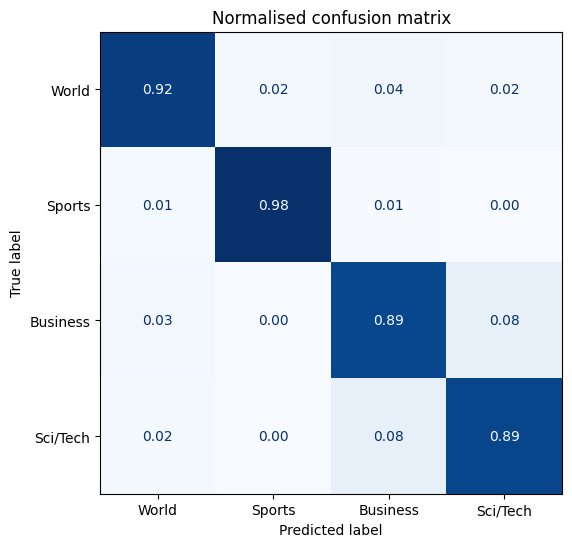

In [18]:
# 混同行列（真陽性偽陽性など）でモデルの性能を確認する

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 予測されたラベルをIDに変換する
label_to_id = {name: i for i, name in enumerate(label_names)}
preds_labels = [int(pred["label"].split('_')[1]) for pred in model_preds] # ここを修正

#混同行列を求める
confusion_matrix = evaluate.load("confusion_matrix")
cm = confusion_matrix.compute(
    references=references,
    predictions=preds_labels,
    normalize="true"
)["confusion_matrix"]

# 混同行列をプロットする
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalised confusion matrix")
plt.show()

6.1.7 今でも役に立つのか

以前として小型のカスタム分類機が役に立つことはある。とりわけ速度と効率が重要なアプリケーションでは。
例えば超大規模言語モデルの訓練データの準備で有用。大量の訓練データを大規模モデルに投入するのはコストが高い。
また、検索システム向けに埋め込みを得ることにも使える。
とはいえ、やはり高性能モデルの利用に移行しつつあるのが現状。